<a href="https://colab.research.google.com/github/Zouzzou21/TIP-Projet-IRM-Cerveau/blob/main/TUMOR_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pathlib
import os

data_dir = pathlib.Path('./ENTRAINEMENT')
print(data_dir)
print(os.path.abspath(data_dir))

image_count = len(list(data_dir.glob('*/*')))
print(image_count)

ENTRAINEMENT
/content/ENTRAINEMENT
394


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!unzip gdrive/My\ Drive/ENTRAINEMENT.zip

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Archive:  gdrive/My Drive/ENTRAINEMENT.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of gdrive/My Drive/ENTRAINEMENT.zip or
        gdrive/My Drive/ENTRAINEMENT.zip.zip, and cannot find gdrive/My Drive/ENTRAINEMENT.zip.ZIP, period.


In [ ]:
batch_size = 4
img_height = 500
img_width = 500

train_data = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  )

val_data = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = val_data.class_names
print(class_names)

Found 392 files belonging to 4 classes.
Using 314 files for training.
Found 392 files belonging to 4 classes.
Using 78 files for validation.
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


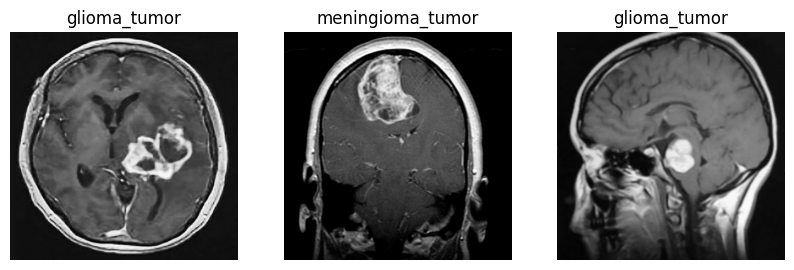

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
from tensorflow.keras import layers

num_classes = 4

model = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(1./255),
    layers.Conv2D(128,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'],)

logdir="logs"

tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir,histogram_freq=1, write_images=logdir,
                                                   embeddings_data=train_data)

model.fit(
    train_data,
  validation_data=val_data,
  epochs=2,
  callbacks=[tensorboard_callback]
)

Epoch 1/2


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5729: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


79/79 [==============================] - 745s 9s/step - loss: 1.4046 - accuracy: 0.2771 - val_loss: 1.3776 - val_accuracy: 0.2692
Epoch 2/2
79/79 [==============================] - 738s 9s/step - loss: 1.3369 - accuracy: 0.3599 - val_loss: 1.3412 - val_accuracy: 0.3462


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, None, None, 3)     0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 128)   6272      
                                                                 
 max_pooling2d (MaxPooling2  (None, None, None, 128)   0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 64)    131136    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, None, None, 64)    0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, None, None, 32)    3

Saving image(49).jpg to image(49).jpg


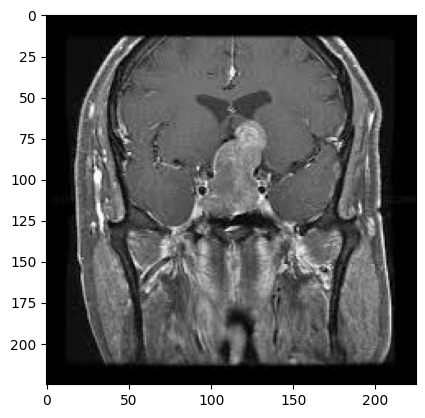

1/1 [==============================] - 0s 431ms/step


[[0.26665923 0.27982566 0.21720143 0.23631372]]




0.27982566


1
Tumeur meningioma !


In [ ]:
import cv2
from google.colab import files

file_to_predict = files.upload()
for file_ in file_to_predict:
    image_to_predict = cv2.imread(file_)
    plt.imshow(image_to_predict)
    plt.show()
    img_to_predict = np.expand_dims(cv2.resize(image_to_predict,(500,500)), axis=0)

    ClassProbability = model.predict(img_to_predict)
    print("\n")
    print(ClassProbability)
    print("\n")

    MAXIMUMClassProbability = np.max(ClassProbability)
    print("\n")
    print (MAXIMUMClassProbability)
    print("\n")

    numpy_array = np.array(ClassProbability)
    val = np.argmax(numpy_array)
    print(val)

    if val == 0:
        print("Tumeur Glioma")
    elif val == 1 :
        print("Tumeur meningioma !")
    elif val == 2  :
        print("Pas de tumeur !")
    elif val == 3 :
        print("Tumeur Pituitary")
